In [1]:
# Import necessary libraries
import pandas as pd
import requests 
import warnings
import numpy as np

In [ ]:
api_key = "Replace with your API Key" 
base_url = "https://api.themoviedb.org/3/movie/"
movie_ids = [0, 299534, 19995, 140607, 299536, 597, 135397, 420818, 24428, 168259, 99861, 284054, 12445, 181808, 330457, 351286, 109445, 321612, 260513]

In [3]:
def fetch_movie_data(movie_ids, api_key, base_url):
    """
    Fetch movie info from TMDB for the list of movie IDs.
    Returns a DataFrame with valid movie data.
    """
    all_movies = []
    base_url = "https://api.themoviedb.org/3/movie/"

    for movie_id in movie_ids:
        if movie_id == 0:
            continue

        url = f"{base_url}{movie_id}?api_key={api_key}&language=en-US&append_to_response=credits"
        try:
            response = requests.get(url)
            response.raise_for_status()
            movie_data = response.json()

            if 'id' not in movie_data:
                warnings.warn(f"Movie ID {movie_id} has no data.")
                continue

            all_movies.append(movie_data)

        except requests.exceptions.HTTPError as http_err:
            warnings.warn(f"HTTP error for ID {movie_id}: {http_err}")
            continue

    return pd.DataFrame(all_movies)

In [4]:
movie_data = fetch_movie_data(movie_ids, api_key, base_url)

In [5]:
def parse_credits_column(df):
    """
    Ensure the 'credits' column is a valid dictionary.
    """
    df['credits'] = df['credits'].apply(lambda x: json.loads(x) if isinstance(x, str) else x)
    return df

In [6]:
def extract_cast_crew_info(credits_dict):
    """
    Extracts top 5 cast names, cast size, director name, and crew size from credits dict.
    """
    if not isinstance(credits_dict, dict):
        return pd.Series([None, None, None, None], index=['cast', 'cast_size', 'director', 'crew_size'])

    cast_list = credits_dict.get('cast', [])
    crew_list = credits_dict.get('crew', [])

    # Get top 5 cast names
    cast_names = [member['name'] for member in cast_list[:5] if 'name' in member]

    # Get director(s)
    directors = [member['name'] for member in crew_list if member.get('job') == 'Director']

    return pd.Series([
        '|'.join(cast_names),
        len(cast_list),
        directors[0] if directors else None,
        len(crew_list)
    ], index=['cast', 'cast_size', 'director', 'crew_size'])

In [7]:
movie_data = parse_credits_column(movie_data)
cast_crew_df = movie_data['credits'].apply(extract_cast_crew_info)

# Merge with the original DataFrame
movie_data = pd.concat([movie_data, cast_crew_df], axis=1)

# Check the updated DataFrame
print(movie_data.columns)

Index(['adult', 'backdrop_path', 'belongs_to_collection', 'budget', 'genres',
       'homepage', 'id', 'imdb_id', 'origin_country', 'original_language',
       'original_title', 'overview', 'popularity', 'poster_path',
       'production_companies', 'production_countries', 'release_date',
       'revenue', 'runtime', 'spoken_languages', 'status', 'tagline', 'title',
       'video', 'vote_average', 'vote_count', 'credits', 'cast', 'cast_size',
       'director', 'crew_size'],
      dtype='object')


In [8]:
print(movie_data)

    adult                     backdrop_path  \
0   False  /7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg   
1   False  /vL5LR6WdxWPjLPFRLe133jXWsh5.jpg   
2   False  /k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg   
3   False  /mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg   
4   False  /sCzcYW9h55WcesOqA12cgEr9Exw.jpg   
5   False  /aIGIYJTyOkEVUmEd3z5x6diYsFx.jpg   
6   False  /1TUg5pO1VZ4B0Q1amk3OlXvlpXV.jpg   
7   False  /9BBTo63ANSmhC4e6r62OJFuK2GL.jpg   
8   False  /cHkhb5A4gQRK6zs6Pv7zorHs8Nk.jpg   
9   False  /6YwkGolwdOMNpbTOmLjoehlVWs5.jpg   
10  False  /b6ZJZHUdMEFECvGiDpJjlfUWela.jpg   
11  False  /n5A7brJCjejceZmHyujwUTVgQNC.jpg   
12  False  /5Iw7zQTHVRBOYpA0V6z0yypOPZh.jpg   
13  False  /AoSZyb37ljMAxw0RdeQEBHKtgcc.jpg   
14  False  /6WA9stUMbIkEPxn3D5SWlA8FIi7.jpg   
15  False  /u2bZhH3nTf0So0UIC1QxAqBvC07.jpg   
16  False  /uU1Mt4JWhDvl4vKb3AfxNsorkoM.jpg   
17  False  /mabuNsGJgRuCTuGqjFkWe1xdu19.jpg   

                                belongs_to_collection     budget  \
0   {'id': 86311, 'name': 'The Avenger

## Data Cleaning and Preprocessing

In [9]:
def drop_irrelevant_columns(df, cols_to_drop):
    """Drop irrelevant columns from the dataframe."""
    return movie_data.drop(columns=cols_to_drop)

In [10]:
cols_to_drop = ['adult', 'imdb_id', 'original_title', 'video', 'homepage']
movie_data = drop_irrelevant_columns(movie_data, cols_to_drop)

In [11]:
def evaluate_json_columns(df, columns_to_check):
    """
    Evaluates the structure of JSON-like columns.
    Prints the data type and a sample value for inspection.
    """
    for col in columns_to_check:
        print(f"\nColumn: {col}")
        print("Data Type of first entry:", type(df[col].iloc[0]))
        print("Sample Value:")
        print(df[col].iloc[0])

In [12]:
json_cols = ['belongs_to_collection', 'genres', 'production_countries',
             'production_companies', 'spoken_languages']

evaluate_json_columns(movie_data, json_cols)


Column: belongs_to_collection
Data Type of first entry: <class 'dict'>
Sample Value:
{'id': 86311, 'name': 'The Avengers Collection', 'poster_path': '/yFSIUVTCvgYrpalUktulvk3Gi5Y.jpg', 'backdrop_path': '/zuW6fOiusv4X9nnW3paHGfXcSll.jpg'}

Column: genres
Data Type of first entry: <class 'list'>
Sample Value:
[{'id': 12, 'name': 'Adventure'}, {'id': 878, 'name': 'Science Fiction'}, {'id': 28, 'name': 'Action'}]

Column: production_countries
Data Type of first entry: <class 'list'>
Sample Value:
[{'iso_3166_1': 'US', 'name': 'United States of America'}]

Column: production_companies
Data Type of first entry: <class 'list'>
Sample Value:
[{'id': 420, 'logo_path': '/hUzeosd33nzE5MCNsZxCGEKTXaQ.png', 'name': 'Marvel Studios', 'origin_country': 'US'}]

Column: spoken_languages
Data Type of first entry: <class 'list'>
Sample Value:
[{'english_name': 'English', 'iso_639_1': 'en', 'name': 'English'}, {'english_name': 'Japanese', 'iso_639_1': 'ja', 'name': '日本語'}, {'english_name': 'Xhosa', 'iso_

In [13]:
def extract_collection_name(df):
    """
    Extract collection name from dictionary.
    """
    df['belongs_to_collection'] = df['belongs_to_collection'].apply(
        lambda x: x['name'] if isinstance(x, dict) else None
    )
    return df

In [14]:
def extract_genre_names(df):
    """
    Extract genre names from the list of dictionaries.
    """
    df['genres'] = df['genres'].apply(
        lambda genres: '|'.join([genre['name'] for genre in genres if 'name' in genre])
        if isinstance(genres, list) else None
    )
    return df

In [15]:
def extract_spoken_languages(df):
    """
    Extract genre names from the list of dictionaries.
    """
    df['spoken_languages'] = df['spoken_languages'].apply(
         lambda langs: '|'.join([lang['english_name'] for lang in langs if 'english_name' in lang])
        if isinstance(langs, list) else None
    )
    return df

In [16]:
def extract_production_countries(df):
    """
    Extract production countries from list of dicts.
    """
    df['production_countries'] = df['production_countries'].apply(
        lambda countries: '|'.join([country['name'] for country in countries if 'name' in country])
        if isinstance(countries, list) else None
    )
    return df

In [17]:
def extract_production_companies(df):
    """
    Extract production companies from list of dicts.
    """
    df['production_companies'] = df['production_companies'].apply(
        lambda companies: '|'.join([company['name'] for company in companies if 'name' in company])
        if isinstance(companies, list) else None
    )
    return df

In [18]:
def extract_all_fields(df):
    """
    Apply all extraction functions to DataFrame.
    """
    df = extract_collection_name(df)
    df = extract_genre_names(df)
    df = extract_spoken_languages(df)
    df = extract_production_countries(df)
    df = extract_production_companies(df)
    return df

In [19]:
movie_data = extract_all_fields(movie_data)

In [20]:
movie_data[['belongs_to_collection', 'genres', 'spoken_languages', 
            'production_countries', 'production_companies']].head()

,belongs_to_collection,genres,spoken_languages,production_countries,production_companies
0,The Avengers Collection,Adventure|Science Fiction|Action,English|Japanese|Xhosa,United States of America,Marvel Studios
1,Avatar Collection,Action|Adventure|Fantasy|Science Fiction,English|Spanish,United States of America|United Kingdom,Dune Entertainment|Lightstorm Entertainment|20...
2,Star Wars Collection,Adventure|Action|Science Fiction,English,United States of America,Lucasfilm Ltd.|Bad Robot
3,The Avengers Collection,Adventure|Action|Science Fiction,English|Xhosa,United States of America,Marvel Studios
4,None,Drama|Romance,English|French|German|Swedish|Italian|Russian,United States of America,Paramount Pictures|20th Century Fox|Lightstorm...


In [21]:
def check_column_values(df, column_name, show_top=10):
    """
    Checking value counts — null, and frequent values.
    
    Args:
        df (DataFrame): Your dataset.
        col (str): Column name you wanna inspect.
        show_top (int): Number of top values to print.
    """
    print(f"\n Checking column: {column_name}")
    print("-" * 30)
    
    # Check missing values
    missing = df[col].isna().sum()
    print(f"Missing values: {missing}")

    # Show top frequent values
    print(f"\nTop {show_top} values:")
    print(df[col].value_counts(dropna=False).head(show_top))

In [22]:
columns_to_check = [
    'belongs_to_collection',
    'genres',
    'spoken_languages',
    'production_countries',
    'production_companies'
]

for col in columns_to_check:
    check_column_values(movie_data, col)


 Checking column: belongs_to_collection
------------------------------
Missing values: 2

Top 10 values:
belongs_to_collection
The Avengers Collection                4
Star Wars Collection                   2
None                                   2
Jurassic Park Collection               2
Frozen Collection                      2
Avatar Collection                      1
The Lion King (Reboot) Collection      1
The Fast and the Furious Collection    1
Black Panther Collection               1
Harry Potter Collection                1
Name: count, dtype: int64

 Checking column: genres
------------------------------
Missing values: 0

Top 10 values:
genres
Adventure|Action|Science Fiction             3
Action|Adventure|Science Fiction|Thriller    2
Action|Adventure|Science Fiction             2
Adventure|Science Fiction|Action             1
Action|Adventure|Fantasy|Science Fiction     1
Drama|Romance                                1
Adventure|Drama|Family|Animation             1
Science F

In [23]:
# Check datatypes of all columns
print(movie_data.dtypes)

backdrop_path             object
belongs_to_collection     object
budget                     int64
genres                    object
id                         int64
origin_country            object
original_language         object
overview                  object
popularity               float64
poster_path               object
production_companies      object
production_countries      object
release_date              object
revenue                    int64
runtime                    int64
spoken_languages          object
status                    object
tagline                   object
title                     object
vote_average             float64
vote_count                 int64
credits                   object
cast                      object
cast_size                  int64
director                  object
crew_size                  int64
dtype: object


In [24]:
# Convert columns to appropriate datatypes
def convert_column_datatypes(df):
    """
    Convert columns to appropriate datatypes.
    """
    # Convert 'budget', 'id', 'popularity', 'revenue', 'runtime', 'vote_count' to numeric
    df['budget'] = pd.to_numeric(df['budget'], errors='coerce')
    df['id'] = pd.to_numeric(df['id'], errors='coerce')
    df['popularity'] = pd.to_numeric(df['popularity'], errors='coerce')
    df['revenue'] = pd.to_numeric(df['revenue'], errors='coerce')
    df['runtime'] = pd.to_numeric(df['runtime'], errors='coerce')
    df['vote_count'] = pd.to_numeric(df['vote_count'], errors='coerce')

    # Convert 'release_date' to datetime
    df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

    return df

In [25]:
# After defining your DataFrame (movie_data)
movie_data = convert_column_datatypes(movie_data)

# Check if the datatypes are correctly converted
print(movie_data.dtypes)

backdrop_path                    object
belongs_to_collection            object
budget                            int64
genres                           object
id                                int64
origin_country                   object
original_language                object
overview                         object
popularity                      float64
poster_path                      object
production_companies             object
production_countries             object
release_date             datetime64[ns]
revenue                           int64
runtime                           int64
spoken_languages                 object
status                           object
tagline                          object
title                            object
vote_average                    float64
vote_count                        int64
credits                          object
cast                             object
cast_size                         int64
director                         object


In [26]:
# Replace unrealistic values in columns
def replace_unrealistic_values(df):
    """
    Replace unrealistic values with NaN for specific columns.
    """
    # Replace 0 values with NaN in 'budget', 'revenue', and 'runtime'
    df['budget'].replace(0, np.nan, inplace=True)
    df['revenue'].replace(0, np.nan, inplace=True)
    df['runtime'].replace(0, np.nan, inplace=True)
    
    return df

In [27]:
movie_data = replace_unrealistic_values(movie_data)

C:\Users\j\AppData\Local\Temp\ipykernel_26400\1220146077.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['budget'].replace(0, np.nan, inplace=True)
C:\Users\j\AppData\Local\Temp\ipykernel_26400\1220146077.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when 

In [28]:
# Convert budget and revenue to million USD
def convert_to_million(df):
    """
    Convert 'budget' and 'revenue' to million USD.
    """
    df['budget_musd'] = df['budget'] / 1_000_000
    df['revenue_musd'] = df['revenue'] / 1_000_000
    return df

In [29]:
movie_data = convert_to_million(movie_data)

In [30]:
# Filter and view movies with vote_count == 0 before adjustment
# before_adjustment = movie_data[movie_data['vote_count'] == 0][['title', 'genres', 'vote_count', 'vote_average']].head(10)

In [31]:
# before_adjustment

In [32]:
# Adjust 'vote_average' for movies with 'vote_count' == 0
import numpy as np
def adjust_vote_average_by_genre(df):
    """
    Adjust 'vote_average' for movies with vote_count == 0 using the average vote of movies 
    within the same genre.
    """
    # Make a copy of the DataFrame to avoid modifying the original
    df = df.copy()

    # Filter out movies that have vote_count > 0, then explode genres for groupby
    rated_movies = df[df['vote_count'] > 0].explode('genres')

    # Compute average vote per genre
    genre_avg_votes = (
        rated_movies.groupby('genres')['vote_average']
        .mean()
        .reset_index()
        .rename(columns={'vote_average': 'genre_vote_avg'})
    )

    # Explode genres again for the full dataset (to apply genre averages)
    df_exploded = df.explode('genres')

    # Merge genre average votes into the exploded DataFrame
    df_exploded = df_exploded.merge(genre_avg_votes, on='genres', how='left')

    # Update vote_average for movies with vote_count == 0
    df_exploded['vote_average'] = np.where(
        df_exploded['vote_count'] == 0,
        df_exploded['genre_vote_avg'],
        df_exploded['vote_average']
    )

    # Reconstruct the original format — one row per movie
    df_updated = df_exploded.groupby('id', as_index=False).first()

    # Drop helper column used for merging
    df_updated.drop(columns=['genre_vote_avg'], inplace=True)

    return df_updated

In [33]:
movie_data = adjust_vote_average_by_genre(movie_data)

In [34]:
movie_data[['title', 'genres', 'vote_count', 'vote_average']].head(10)

,title,genres,vote_count,vote_average
0,Titanic,Drama|Romance,25882,7.905
1,Harry Potter and the Deathly Hallows: Part 2,Fantasy|Adventure,20951,8.087
2,Avatar,Action|Adventure|Fantasy|Science Fiction,32139,7.588
3,The Avengers,Science Fiction|Action|Adventure,31550,7.736
4,Avengers: Age of Ultron,Action|Adventure|Science Fiction,23358,7.271
5,Frozen,Animation|Family|Adventure|Fantasy,16796,7.200
6,Jurassic World,Action|Adventure|Science Fiction|Thriller,20636,6.693
7,Star Wars: The Force Awakens,Adventure|Action|Science Fiction,19676,7.300
8,Furious 7,Action|Thriller|Crime,10766,7.226
9,Star Wars: The Last Jedi,Adventure|Action|Science Fiction,15542,6.780


In [35]:
def view_placeholder_entries(df, columns, placeholder='No Data'):
    """
    Return rows where specified columns contain a given placeholder.
    """
    condition = False
    for col in columns:
        condition |= (df[col] == placeholder)
    return df[condition][['title'] + columns]

In [36]:
view_placeholder_entries(movie_data, ['overview', 'tagline'])

,title,overview,tagline


In [37]:
# Replace known placeholders in 'overview' and 'tagline' with NaN
def replace_placeholders(df):
    """
    Replace placeholders in 'overview' and 'tagline' with NaN.
    """
    df = df.copy()  # always play it safe with copies if you're modifying
    df['overview'] = df['overview'].replace('No Data', np.nan)
    df['tagline'] = df['tagline'].replace('No Data', np.nan)
    return df

In [38]:
movie_data = replace_placeholders(movie_data)

In [39]:
def drop_invalid_rows_dsa(df):
    """
    Remove duplicate rows by 'id' and drop rows with missing 'id' or 'title',
    using Python data structures (set, list).
    """
    seen_ids = set()
    unique_rows = []

    for _, row in df.iterrows():
        movie_id = row['id']
        title = row['title']

        # Skip rows with missing id or title
        if pd.isna(movie_id) or pd.isna(title):
            continue

        # Skip duplicate ids
        if movie_id in seen_ids:
            continue

        seen_ids.add(movie_id)
        unique_rows.append(row)

    # Create a new DataFrame from valid, unique rows
    clean_df = pd.DataFrame(unique_rows)

    return clean_df

In [40]:
clean_df = movie_data.copy()  

In [41]:
clean_movie_data = drop_invalid_rows_dsa(clean_df)

In [42]:
clean_movie_data

,id,backdrop_path,belongs_to_collection,budget,genres,origin_country,original_language,overview,popularity,poster_path,...,title,vote_average,vote_count,credits,cast,cast_size,director,crew_size,budget_musd,revenue_musd
0,597,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,None,200000000,Drama|Romance,[US],en,101-year-old Rose DeWitt Bukater tells the sto...,42.3313,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,...,Titanic,7.905,25882,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,258,200.0,2264.162353
1,12445,/n5A7brJCjejceZmHyujwUTVgQNC.jpg,Harry Potter Collection,125000000,Fantasy|Adventure,[GB],en,"Harry, Ron and Hermione continue their quest t...",22.1718,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,...,Harry Potter and the Deathly Hallows: Part 2,8.087,20951,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,104,David Yates,154,125.0,1341.511219
2,19995,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,Avatar Collection,237000000,Action|Adventure|Fantasy|Science Fiction,[US],en,"In the 22nd century, a paraplegic Marine is di...",32.6439,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,...,Avatar,7.588,32139,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,65,James Cameron,986,237.0,2923.706026
3,24428,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,The Avengers Collection,220000000,Science Fiction|Action|Adventure,[US],en,When an unexpected enemy emerges and threatens...,41.7467,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,...,The Avengers,7.736,31550,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,631,220.0,1518.815515
4,99861,/6YwkGolwdOMNpbTOmLjoehlVWs5.jpg,The Avengers Collection,365000000,Action|Adventure|Science Fiction,[US],en,When Tony Stark tries to jumpstart a dormant p...,20.9173,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,...,Avengers: Age of Ultron,7.271,23358,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,72,Joss Whedon,636,365.0,1405.403694
5,109445,/u2bZhH3nTf0So0UIC1QxAqBvC07.jpg,Frozen Collection,150000000,Animation|Family|Adventure|Fantasy,[US],en,Young princess Anna of Arendelle dreams about ...,23.4726,/m4uhSpErBKprhsclr0zynTYdupb.jpg,...,Frozen,7.200,16796,"{'cast': [{'adult': False, 'gender': 1, 'id': ...",Kristen Bell|Idina Menzel|Jonathan Groff|Josh ...,60,Jennifer Lee,284,150.0,1274.219009
6,135397,/aIGIYJTyOkEVUmEd3z5x6diYsFx.jpg,Jurassic Park Collection,150000000,Action|Adventure|Science Fiction|Thriller,[US],en,Twenty-two years after the events of Jurassic ...,23.7317,/rhr4y79GpxQF9IsfJItRXVaoGs4.jpg,...,Jurassic World,6.693,20636,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Chris Pratt|Bryce Dallas Howard|Irrfan Khan|Vi...,52,Colin Trevorrow,423,150.0,1671.537444
7,140607,/k6EOrckWFuz7I4z4wiRwz8zsj4H.jpg,Star Wars Collection,245000000,Adventure|Action|Science Fiction,[US],en,Thirty years after defeating the Galactic Empi...,18.0488,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,...,Star Wars: The Force Awakens,7.300,19676,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Harrison Ford|Mark Hamill|Carrie Fisher|Adam D...,182,J.J. Abrams,257,245.0,2068.223624
8,168259,/cHkhb5A4gQRK6zs6Pv7zorHs8Nk.jpg,The Fast and the Furious Collection,190000000,Action|Thriller|Crime,[US],en,Deckard Shaw seeks revenge against Dominic Tor...,17.6978,/wurKlC3VKUgcfsn0K51MJYEleS2.jpg,...,Furious 7,7.226,10766,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Vin Diesel|Paul Walker|Jason Statham|Michelle ...,48,James Wan,222,190.0,1515.400000
9,181808,/5Iw7zQTHVRBOYpA0V6z0yypOPZh.jpg,Star Wars Collection,200000000,Adventure|Action|Science Fiction,[US],en,Rey develops her newly discovered abilities wi...,14.1546,/kOVEVeg59E0wsnXmF9nrh6OmWII.jpg,...,Star Wars: The Last Jedi,6.780,15542,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Mark Hamill|Carrie Fisher|Adam Driver|Daisy Ri...,110,Rian Johnson,213,200.0,1332.698830


In [43]:
# Keep only rows with at least 10 non-NaN values
def filter_non_nan_rows(df):
    """
    Keep only rows with at least 10 non-NaN values.
    """
    return df[df.notna().sum(axis=1) >= 10]

In [44]:
filtered_movie_data = filter_non_nan_rows(clean_movie_data)

In [45]:
# Filter only 'Released' movies and drop 'status' column
def filter_released_movies(df):
    """
    Keep only 'Released' movies and drop 'status' column.
    """
    df = df[df['status'] == 'Released']
    df.drop(columns=['status'], inplace=True)
    return df

In [46]:
released_movie_data = filter_released_movies(filtered_movie_data)

In [47]:
released_movie_data.head()

,id,backdrop_path,belongs_to_collection,budget,genres,origin_country,original_language,overview,popularity,poster_path,...,title,vote_average,vote_count,credits,cast,cast_size,director,crew_size,budget_musd,revenue_musd
0,597,/sCzcYW9h55WcesOqA12cgEr9Exw.jpg,None,200000000,Drama|Romance,[US],en,101-year-old Rose DeWitt Bukater tells the sto...,42.3313,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,...,Titanic,7.905,25882,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,258,200.0,2264.162353
1,12445,/n5A7brJCjejceZmHyujwUTVgQNC.jpg,Harry Potter Collection,125000000,Fantasy|Adventure,[GB],en,"Harry, Ron and Hermione continue their quest t...",22.1718,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,...,Harry Potter and the Deathly Hallows: Part 2,8.087,20951,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,104,David Yates,154,125.0,1341.511219
2,19995,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,Avatar Collection,237000000,Action|Adventure|Fantasy|Science Fiction,[US],en,"In the 22nd century, a paraplegic Marine is di...",32.6439,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,...,Avatar,7.588,32139,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,65,James Cameron,986,237.0,2923.706026
3,24428,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,The Avengers Collection,220000000,Science Fiction|Action|Adventure,[US],en,When an unexpected enemy emerges and threatens...,41.7467,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,...,The Avengers,7.736,31550,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,631,220.0,1518.815515
4,99861,/6YwkGolwdOMNpbTOmLjoehlVWs5.jpg,The Avengers Collection,365000000,Action|Adventure|Science Fiction,[US],en,When Tony Stark tries to jumpstart a dormant p...,20.9173,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,...,Avengers: Age of Ultron,7.271,23358,"{'cast': [{'adult': False, 'gender': 2, 'id': ...",Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,72,Joss Whedon,636,365.0,1405.403694


In [48]:
# Reorder columns
def reorder_columns(df):
    """
    Reorder the DataFrame columns based on the guide.
    """
    final_columns_order = [
        'id', 'title', 'tagline', 'release_date', 'genres', 'belongs_to_collection',
        'original_language', 'budget_musd', 'revenue_musd', 'production_companies',
        'production_countries', 'vote_count', 'vote_average', 'popularity', 'runtime',
        'overview', 'spoken_languages', 'poster_path', 'cast', 'cast_size', 'director', 'crew_size'
    ]
    
    return df[final_columns_order]

In [49]:
# Call the function to reorder columns
final_movie_data = reorder_columns(released_movie_data)

# Check the top rows of the reordered DataFrame
final_movie_data.head()

,id,title,tagline,release_date,genres,belongs_to_collection,original_language,budget_musd,revenue_musd,production_companies,...,vote_average,popularity,runtime,overview,spoken_languages,poster_path,cast,cast_size,director,crew_size
0,597,Titanic,Nothing on Earth could come between them.,1997-11-18,Drama|Romance,None,en,200.0,2264.162353,Paramount Pictures|20th Century Fox|Lightstorm...,...,7.905,42.3313,194,101-year-old Rose DeWitt Bukater tells the sto...,English|French|German|Swedish|Italian|Russian,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,258
1,12445,Harry Potter and the Deathly Hallows: Part 2,It all ends.,2011-07-12,Fantasy|Adventure,Harry Potter Collection,en,125.0,1341.511219,Warner Bros. Pictures|Heyday Films,...,8.087,22.1718,130,"Harry, Ron and Hermione continue their quest t...",English,/c54HpQmuwXjHq2C9wmoACjxoom3.jpg,Daniel Radcliffe|Emma Watson|Rupert Grint|Ralp...,104,David Yates,154
2,19995,Avatar,Enter the world of Pandora.,2009-12-15,Action|Adventure|Fantasy|Science Fiction,Avatar Collection,en,237.0,2923.706026,Dune Entertainment|Lightstorm Entertainment|20...,...,7.588,32.6439,162,"In the 22nd century, a paraplegic Marine is di...",English|Spanish,/kyeqWdyUXW608qlYkRqosgbbJyK.jpg,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,65,James Cameron,986
3,24428,The Avengers,Some assembly required.,2012-04-25,Science Fiction|Action|Adventure,The Avengers Collection,en,220.0,1518.815515,Marvel Studios,...,7.736,41.7467,143,When an unexpected enemy emerges and threatens...,English|Hindi|Russian,/RYMX2wcKCBAr24UyPD7xwmjaTn.jpg,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,112,Joss Whedon,631
4,99861,Avengers: Age of Ultron,A new age has come.,2015-04-22,Action|Adventure|Science Fiction,The Avengers Collection,en,365.0,1405.403694,Marvel Studios,...,7.271,20.9173,141,When Tony Stark tries to jumpstart a dormant p...,English,/4ssDuvEDkSArWEdyBl2X5EHvYKU.jpg,Robert Downey Jr.|Chris Hemsworth|Mark Ruffalo...,72,Joss Whedon,636


In [50]:
# Reset index
def reset_index(df):
    """
    Reset index of the DataFrame.
    """
    df.reset_index(drop=True, inplace=True)
    return df

In [51]:
# After cleaning and preprocessing
movie_data = reset_index(movie_data)

# Check the first few rows
print(movie_data.head())

      id                     backdrop_path    belongs_to_collection  \
0    597  /sCzcYW9h55WcesOqA12cgEr9Exw.jpg                     None   
1  12445  /n5A7brJCjejceZmHyujwUTVgQNC.jpg  Harry Potter Collection   
2  19995  /vL5LR6WdxWPjLPFRLe133jXWsh5.jpg        Avatar Collection   
3  24428  /9BBTo63ANSmhC4e6r62OJFuK2GL.jpg  The Avengers Collection   
4  99861  /6YwkGolwdOMNpbTOmLjoehlVWs5.jpg  The Avengers Collection   

      budget                                    genres origin_country  \
0  200000000                             Drama|Romance           [US]   
1  125000000                         Fantasy|Adventure           [GB]   
2  237000000  Action|Adventure|Fantasy|Science Fiction           [US]   
3  220000000          Science Fiction|Action|Adventure           [US]   
4  365000000          Action|Adventure|Science Fiction           [US]   

  original_language                                           overview  \
0                en  101-year-old Rose DeWitt Bukater tells 

In [52]:
# Check datatypes of all columns
print(movie_data.dtypes)

id                                int64
backdrop_path                    object
belongs_to_collection            object
budget                            int64
genres                           object
origin_country                   object
original_language                object
overview                         object
popularity                      float64
poster_path                      object
production_companies             object
production_countries             object
release_date             datetime64[ns]
revenue                           int64
runtime                           int64
spoken_languages                 object
status                           object
tagline                          object
title                            object
vote_average                    float64
vote_count                        int64
credits                          object
cast                             object
cast_size                         int64
director                         object


In [53]:
# Main function to clean the DataFrame
def clean_movie_data(df):
    """
    Clean the movie data using various data cleaning functions.
    """
    # Step-by-step application of each function
    df = convert_column_datatypes(df)
    df = replace_unrealistic_values(df)
    df = convert_to_million(df)
    df = adjust_vote_average_by_genre(df)
    df = replace_placeholders(df)
    df = drop_invalid_rows_dsa(df)
    df = filter_non_nan_rows(df)
    df = filter_released_movies(df)
    df = reorder_columns(df)
    df = reset_index(df)

    return df


tmdb_final = clean_movie_data(movie_data)

C:\Users\j\AppData\Local\Temp\ipykernel_26400\1220146077.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['budget'].replace(0, np.nan, inplace=True)
C:\Users\j\AppData\Local\Temp\ipykernel_26400\1220146077.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when 

## Analysis 

In [54]:
def calculate_profit(row):
    """
    Calculate profit as Revenue - Budget.
    """
    return row['revenue_musd'] - row['budget_musd']

In [55]:
def calculate_roi(row):
    """
    Calculate ROI as Revenue / Budget (only for Budget ≥ 10M).
    """
    return row['revenue_musd'] / row['budget_musd'] if row['budget_musd'] >= 10_000_000 else None

In [56]:
def kpi_ranking(df):
    """
    Rank movies based on various KPIs (Revenue, Budget, Profit, ROI, etc.).
    """
    # Calculate Profit and ROI
    df['profit'] = df.apply(calculate_profit, axis=1)
    df['roi'] = df.apply(calculate_roi, axis=1)
    
    # Filter movies with Budget ≥ 10M for ROI ranking
    filtered_df = df[df['budget_musd'] >= 10_000_000]

    # Ranking based on KPIs
    highest_revenue = df.sort_values(by='revenue_musd', ascending=False).head(1)
    highest_budget = df.sort_values(by='budget_musd', ascending=False).head(1)
    highest_profit = df.sort_values(by='profit', ascending=False).head(1)
    lowest_profit = df.sort_values(by='profit').head(1)
    highest_roi = filtered_df.sort_values(by='roi', ascending=False).head(1)
    lowest_roi = filtered_df.sort_values(by='roi').head(1)
    most_voted = df.sort_values(by='vote_count', ascending=False).head(1)
    highest_rated = df[df['vote_count'] >= 10].sort_values(by='vote_average', ascending=False).head(1)
    lowest_rated = df[df['vote_count'] >= 10].sort_values(by='vote_average').head(1)
    most_popular = df.sort_values(by='popularity', ascending=False).head(1)
    
    return {
        "Highest Revenue": highest_revenue,
        "Highest Budget": highest_budget,
        "Highest Profit": highest_profit,
        "Lowest Profit": lowest_profit,
        "Highest ROI": highest_roi,
        "Lowest ROI": lowest_roi,
        "Most Voted": most_voted,
        "Highest Rated": highest_rated,
        "Lowest Rated": lowest_rated,
        "Most Popular": most_popular
    }


In [57]:
def filter_movies(df, genre=None, actor=None, director=None, min_votes=0, min_budget=0, sort_by=None):
    """
    Filter movies based on specific criteria: genre, actor, director, min_votes, min_budget, and sorting.
    """
    if genre:
        df = df[df['genres'].str.contains(genre, case=False, na=False)]
    if actor:
        df = df[df['cast'].str.contains(actor, case=False, na=False)]
    if director:
        df = df[df['director'].str.contains(director, case=False, na=False)]
    if min_votes > 0:
        df = df[df['vote_count'] >= min_votes]
    if min_budget > 0:
        df = df[df['budget_musd'] >= min_budget]
    if sort_by:
        df = df.sort_values(by=sort_by, ascending=False)
    
    return df

# Search 1: Find the best-rated Science Fiction Action movies starring Bruce Willis
search_1 = filter_movies(movie_data, genre="Science Fiction|Action", actor="Bruce Willis", sort_by="vote_average")

# Search 2: Find movies starring Uma Thurman, directed by Quentin Tarantino
search_2 = filter_movies(movie_data, actor="Uma Thurman", director="Quentin Tarantino", sort_by="runtime")

In [63]:
def franchise_vs_standalone(df):
    """
    Compare franchise vs standalone movies in terms of: 
    Mean Revenue, Median ROI, Mean Budget, Mean Popularity, Mean Rating.
    """
    franchise_movies = df[df['belongs_to_collection'].notna()]
    standalone_movies = df[df['belongs_to_collection'].isna()]
    
    franchise_stats = {
        'Mean Revenue': franchise_movies['revenue_musd'].mean(),
        'Median ROI': franchise_movies['roi'].median(),
        'Mean Budget': franchise_movies['budget_musd'].mean(),
        'Mean Popularity': franchise_movies['popularity'].mean(),
        'Mean Rating': franchise_movies['vote_average'].mean()
    }
    
    standalone_stats = {
        'Mean Revenue': standalone_movies['revenue_musd'].mean(),
        'Median ROI': standalone_movies['roi'].median(),
        'Mean Budget': standalone_movies['budget_musd'].mean(),
        'Mean Popularity': standalone_movies['popularity'].mean(),
        'Mean Rating': standalone_movies['vote_average'].mean()
    }
    
    return franchise_stats, standalone_stats

In [68]:
def most_successful_franchises(df):
    """
    Find the most successful movie franchises based on:
    - Total number of movies in franchise
    - Total & Mean Budget
    - Total & Mean Revenue
    - Mean Rating
    """
    franchises = df[df['belongs_to_collection'].notna()]
    
    franchise_groups = franchises.groupby('belongs_to_collection').agg(
        movie_count=('id', 'count'),
        total_budget=('budget_musd', 'sum'),
        mean_budget=('budget_musd', 'mean'),
        total_revenue=('revenue_musd', 'sum'),
        mean_revenue=('revenue_musd', 'mean'),
        mean_rating=('vote_average', 'mean')
    )
    
    return franchise_groups.sort_values(by='movie_count', ascending=False)

In [69]:
def most_successful_directors(df):
    """
    Find the most successful directors based on:
    - Total Number of Movies Directed
    - Total Revenue
    - Mean Rating
    """
    directors = df.groupby('director').agg(
        movie_count=('id', 'count'),
        total_revenue=('revenue_musd', 'sum'),
        mean_rating=('vote_average', 'mean')
    )
    
    return directors.sort_values(by='movie_count', ascending=False)

In [70]:
def analyze_movie_data(df):
    # Calculate KPI rankings
    kpi_results = kpi_ranking(df)
    print("KPI Rankings:", kpi_results)
    
    # Search 1: Best-rated Science Fiction Action movies starring Bruce Willis
    search_1 = filter_movies(df, genre="Science Fiction|Action", actor="Bruce Willis", sort_by="vote_average")
    print("\nBest-rated Science Fiction Action Movies starring Bruce Willis:", search_1)

    # Search 2: Movies starring Uma Thurman, directed by Quentin Tarantino
    search_2 = filter_movies(df, actor="Uma Thurman", director="Quentin Tarantino", sort_by="runtime")
    print("\nMovies starring Uma Thurman, directed by Quentin Tarantino:", search_2)
    
    # Franchise vs Standalone Movie Comparison
    franchise_stats, standalone_stats = franchise_vs_standalone(df)
    print("\nFranchise Movie Stats:", franchise_stats)
    print("Standalone Movie Stats:", standalone_stats)

    # Most Successful Franchises
    franchise_success = most_successful_franchises(df)
    print("\nMost Successful Movie Franchises:", franchise_success)

    # Most Successful Directors
    director_success = most_successful_directors(df)
    print("\nMost Successful Directors:", director_success)


In [71]:
tmdb_final = analyze_movie_data(tmdb_final)

KPI Rankings: {'Highest Revenue':       id   title                      tagline release_date  \
2  19995  Avatar  Enter the world of Pandora.   2009-12-15   

                                     genres belongs_to_collection  \
2  Action|Adventure|Fantasy|Science Fiction     Avatar Collection   

  original_language  budget_musd  revenue_musd  \
2                en        237.0   2923.706026   

                                production_companies  ... runtime  \
2  Dune Entertainment|Lightstorm Entertainment|20...  ...     162   

                                            overview  spoken_languages  \
2  In the 22nd century, a paraplegic Marine is di...   English|Spanish   

                        poster_path  \
2  /kyeqWdyUXW608qlYkRqosgbbJyK.jpg   

                                                cast cast_size       director  \
2  Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...        65  James Cameron   

  crew_size       profit   roi  
2       986  2686.706026  None  

[1 r

c:\Users\j\anaconda3\envs\creating_an_environment\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\j\anaconda3\envs\creating_an_environment\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


## Data Visualization

In [78]:
import matplotlib.pyplot as plt

def plot_revenue_musd_vs_budget_musd(df):
    plt.scatter(df['budget'], df['revenue'])
    plt.title('Revenue vs. Budget Trends')
    plt.xlabel('Budget')
    plt.ylabel('Revenue')
    plt.show()

In [79]:
def plot_roi_distribution_by_genre(df):
    df['roi'] = df['revenue_musd'] / df['budget_musd']
    df_genre_roi = df.groupby('genres')['roi'].mean()
    df_genre_roi.plot(kind='bar')
    plt.title('ROI Distribution by Genre')
    plt.xlabel('Genre')
    plt.ylabel('Average ROI')
    plt.show()

In [80]:
def plot_popularity_vs_rating(df):
    plt.scatter(df['popularity'], df['vote_average'])
    plt.title('Popularity vs. Rating')
    plt.xlabel('Popularity')
    plt.ylabel('Rating')
    plt.show()

In [81]:
def plot_yearly_trends(df):
    df['year'] = df['release_date'].dt.year
    yearly_trends = df.groupby('year').agg(
        total_revenue=('revenue_musd', 'sum'),
        mean_rating=('vote_average', 'mean')
    )
    yearly_trends.plot(kind='line')
    plt.title('Yearly Trends in Box Office Performance')
    plt.xlabel('Year')
    plt.ylabel('Total Revenue')
    plt.show()

In [82]:
def plot_franchise_vs_standalone(df):
    franchise_stats, standalone_stats = franchise_vs_standalone(df)
    
    # Plot
    labels = ['Franchise', 'Standalone']
    revenue = [franchise_stats['Mean Revenue'], standalone_stats['Mean Revenue']]
    plt.bar(labels, revenue)
    plt.title('Franchise vs. Standalone Revenue Comparison')
    plt.ylabel('Mean Revenue')
    plt.show()

{'Highest Revenue':       id                     backdrop_path belongs_to_collection     budget  \
2  19995  /vL5LR6WdxWPjLPFRLe133jXWsh5.jpg     Avatar Collection  237000000   

                                     genres origin_country original_language  \
2  Action|Adventure|Fantasy|Science Fiction           [US]                en   

                                            overview  popularity  \
2  In the 22nd century, a paraplegic Marine is di...     32.6439   

                        poster_path  ... vote_count  \
2  /kyeqWdyUXW608qlYkRqosgbbJyK.jpg  ...      32139   

                                             credits  \
2  {'cast': [{'adult': False, 'gender': 2, 'id': ...   

                                                cast  cast_size  \
2  Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...         65   

        director crew_size budget_musd revenue_musd       profit   roi  
2  James Cameron       986       237.0  2923.706026  2686.706026  None  

[1 rows x 30 colu

c:\Users\j\anaconda3\envs\creating_an_environment\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
c:\Users\j\anaconda3\envs\creating_an_environment\Lib\site-packages\numpy\lib\nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


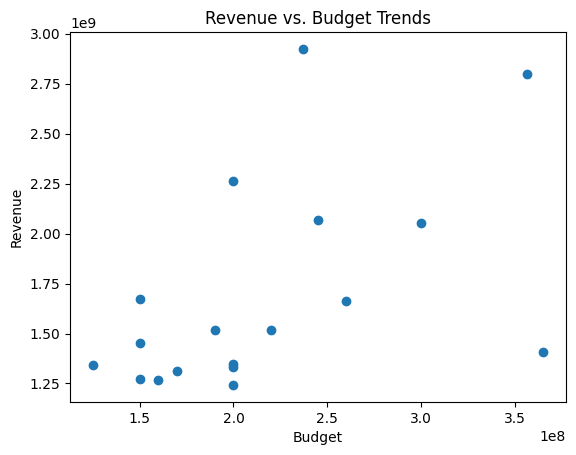

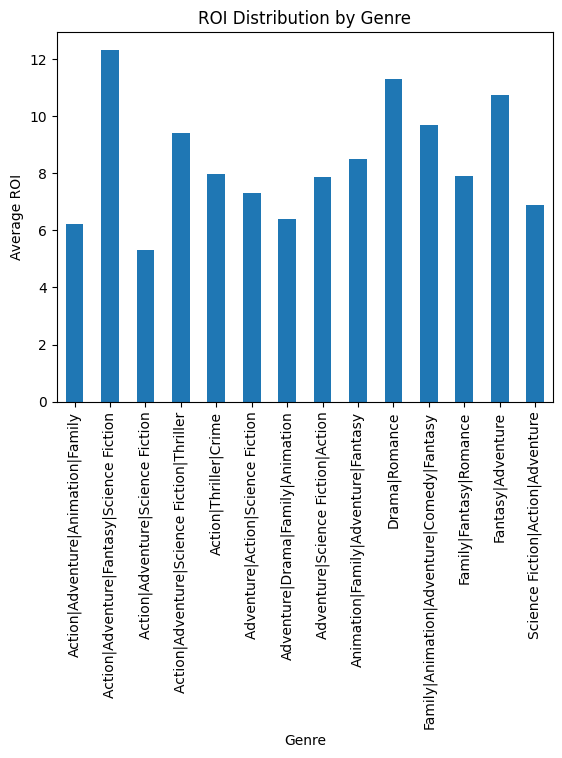

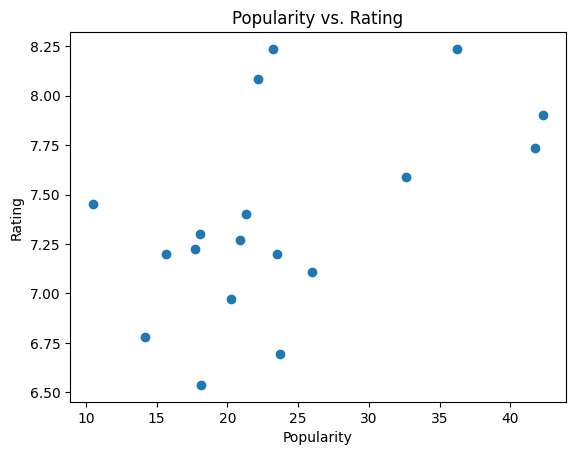

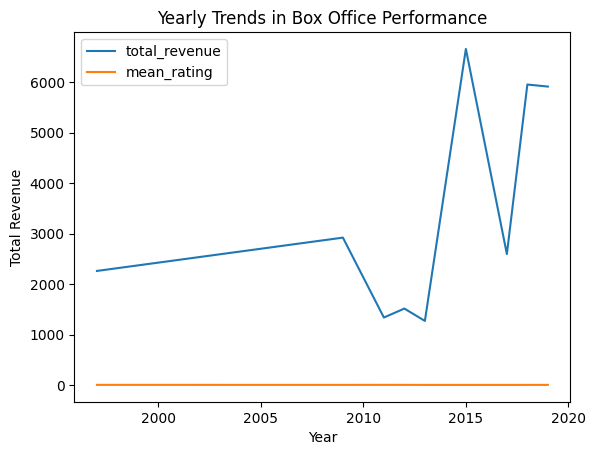

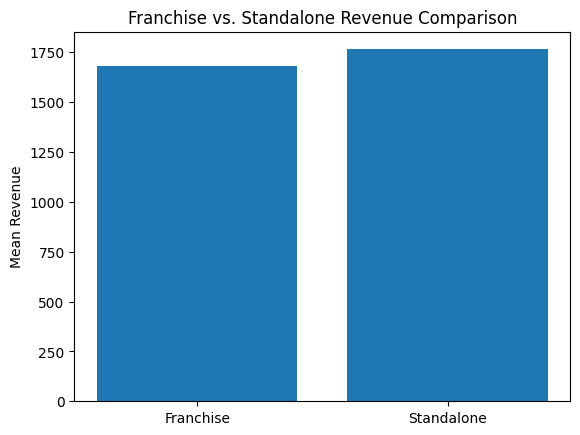

In [83]:
# Apply the analysis functions
kpi_results = kpi_ranking(movie_data)
print(kpi_results)

# Filter movies for advanced search queries
print("Search 1 (Best-rated Sci-Fi Action movies starring Bruce Willis):")
print(search_1)

print("Search 2 (Movies starring Uma Thurman, directed by Quentin Tarantino):")
print(search_2)

# Compare Franchise vs Standalone Movies
franchise_stats, standalone_stats = franchise_vs_standalone(movie_data)
print("Franchise vs Standalone Stats:")
print("Franchise:", franchise_stats)
print("Standalone:", standalone_stats)

# Find most successful franchises
franchises = most_successful_franchises(movie_data)
print("Most Successful Movie Franchises:")
print(franchises)

# Find most successful directors
directors = most_successful_directors(movie_data)
print("Most Successful Directors:")
print(directors)

# Visualizations
plot_revenue_musd_vs_budget_musd(movie_data)
plot_roi_distribution_by_genre(movie_data)
plot_popularity_vs_rating(movie_data)
plot_yearly_trends(movie_data)
plot_franchise_vs_standalone(movie_data)